# Project 
#### *By: Lia Glad, Mathilda Melin and Caroline Stemne*
#
#### **The paper:** Optical Deformability as an Inherent Cell Marker for Testing Malignant Transformation and Metastatic Competence.
#### **The data object:** The paper provided no experimental data, only the mean and standard error of optical deformability for healthy, cancerous and metastatic cells.
#### **The random variable chosen:** The optical deformability.
#### **What the paper does:** The paper examines the optical deformability of different cell types in order to determine if optical deformability potentially can be a diagnostic tool.
#### **The generative model proposed:** Monte Carlo generator.
#### **Parameters and assumptions:** The parameters are mean and standard deviation. A normal distribution is assumed, since optical deformability is a continuous variable. 
#### **The forward simulation:** The forward simulation was created using Monte Carlo with LCG, uniforms and Box Muller. 
#### **The parameterization/fitting:** Parameterization was done by calculating the mean and standard deviation of the generated data. This is then validated using Bootstrap. 
#### **What/if the model adds to the paper:** This model adds a classification tool to estimate the probability of a random test cell being healthy, cancerous or metastatic based on its optical deformability.
#### **Model limitations/how it breaks:** Since there was no experimental data provided in the paper, the parameterization model is inadequate since the data is generated using the given parameters.
#


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

## Calculating standard deviation from standard error

In [2]:
# Standard error for healthy cells (MCF-10), and corresponding sample size for healthy cells
SE_healthy = 0.8 # percent % optical deformability
N_cells_healthy = 36 

# Calculating standard deviation for normal cells
SD_healthy = SE_healthy * np.sqrt(N_cells_healthy)

# Standard error for cancerous cells (MCF-7), and corresponding sample size for cancerous cells
SE_cancer = 1.1 # percent % optical deformability    
N_cells_cancer = 26 

# Calculating standard deviation for cancer cells
SD_cancer = SE_cancer * np.sqrt(N_cells_cancer)

# Standard error for metastatic cells (modMCF-7), and corresponding sample size for metastatic cells
SE_meta = 1.8 # percent % optical deformability  
N_cells_meta = 21 

# Calculating standard deviation for cancer cells
SD_meta = SE_meta * np.sqrt(N_cells_meta)

print(f"Standard deviation for healthy cells: {SD_healthy:.2f}")
print(f"Standard deviation for cancer cells: {SD_cancer:.2f}")
print(f"Standard deviation for metastatic cells: {SD_meta:.2f}")

Standard deviation for healthy cells: 4.80
Standard deviation for cancer cells: 5.61
Standard deviation for metastatic cells: 8.25


## Monte Carlo Generator for random cells

In [3]:
# Sample size
n_samples = 500

# Parameters mu and sigma, mu is the mean value from the paper and sigma is the calculated standard deviation
mu_healthy, sigma_healthy = 10.5, SD_healthy # percent % optical deformability
mu_cancer, sigma_cancer = 21.4, SD_cancer # percent % optical deformability
mu_meta, sigma_meta = 30.4, SD_meta # percent % optical deformability

# Generate random data with normal distribution

# Function for Linear Congruential Generator
def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    next_state = ((a * state) + c) % m
    return next_state

# Defining constants
A = 1664525
C = 1013904223
M = 2 ** 32

# Functions for uniforms
def uniforms(k, seed):
    """A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."""
    out = [0.0] * k
    state = seed
    for i in range(k):
      next_state = lcg(state, A, C, M)
      state_m = next_state / M
      out[i] = state_m
      state = next_state
    return out
    
# Generate normally distributed random numbers using the Box-Muller transformation
def normal_samples(n, seed, mu, sigma):
    rs = uniforms(2 * n, seed) # Box Muller requires two random numbers to produce one normally distributed number
    out = []
    for i in range(n):
        u1 = rs[2 * i]
        u2 = rs[2 * i + 1]
        z = math.sqrt(-2 * math.log(u1)) * math.cos(2 * math.pi * u2)
        x = mu + sigma * z
        out.append(x) # Append one normally distributed number for each loop in the sample size 
    return out

# Generate the three datasets using the normal_samples function
mcf10_data = normal_samples(n_samples, 2026, mu_healthy, sigma_healthy)
mcf7_data = normal_samples(n_samples, 2027, mu_cancer, sigma_cancer)
mod_mcf7_data = normal_samples(n_samples, 2028, mu_meta, sigma_meta)


# Remove values below 0, since there cant be a negative deformation
healthy_data = np.clip(mcf10_data, a_min=0, a_max=None)
cancer_data = np.clip(mcf7_data, a_min=0, a_max=None)
meta_data = np.clip(mod_mcf7_data, a_min=0, a_max=None)

# Print the first 10 observations 
print("Healthy data:")
print(healthy_data[:10])

print("\nCancer data:")
print(cancer_data[:10])

print("\nMetastatic data:")
print(meta_data[:10])

Healthy data:
[23.30701173  4.13314607  6.02523607 10.96540113 19.48117972 16.45627758
 10.08358401 12.67856759 10.72691369  9.93112026]

Cancer data:
[31.66323618 20.00571028 22.3813958  15.82283361 26.30064045 25.35091461
 22.28313245 20.53945686 29.21788364 24.67714627]

Metastatic data:
[33.85105736 29.50265374 32.13929036 22.32914874 43.38915031 27.89020947
 33.78452522 31.136066   38.63680629 33.83382474]


## Building a probabilistic classifier 

In [4]:
# Function to calculate normal distribution (gaussian density)
def normal_distribution(x, mu, sigma):
    coeff = 1 / (sigma * np.sqrt(2 * np.pi))
    exponent = np.exp(-((x - mu) ** 2) / (2 * (sigma ** 2)))
    return coeff * exponent

# Choosing a random cell within the interval
random_cell_OD = np.random.uniform(0.0, 60.0)

# Calculate the probabilities that the random cell is normal and probability that it is cancer
p_healthy = normal_distribution(random_cell_OD, mu_healthy, sigma_healthy) 
p_cancer = normal_distribution(random_cell_OD, mu_cancer, sigma_cancer)
p_meta = normal_distribution(random_cell_OD, mu_meta, sigma_meta)

# Convert the probabilities to percent
total_density = p_healthy + p_cancer + p_meta
prob_healthy_pct = (p_healthy / total_density) * 100
prob_cancer_pct = (p_cancer / total_density) * 100
prob_meta_pct = (p_meta / total_density) * 100

# Store probabilities in a dictionary
probs = {'Healthy': prob_healthy_pct,'Cancer': prob_cancer_pct,'Metastatic': prob_meta_pct}

# Sort classes by probability in descending order
sorted_classes = sorted(probs.items(), key=lambda item: item[1], reverse=True)
top_class, top_prob = sorted_classes[0]
second_class, second_prob = sorted_classes[1]

# Difference between the top probability and the second
difference = top_prob - second_prob

#### Printing and plotting

Classification of a random cell based on probability:

The optical deformability of the random cell: 34.1%
Most likely: Metastatic (88.8%)
Second most likely: Cancer (11.2%)

Conclusion: The cell is classified as Metastatic, with high certainty.



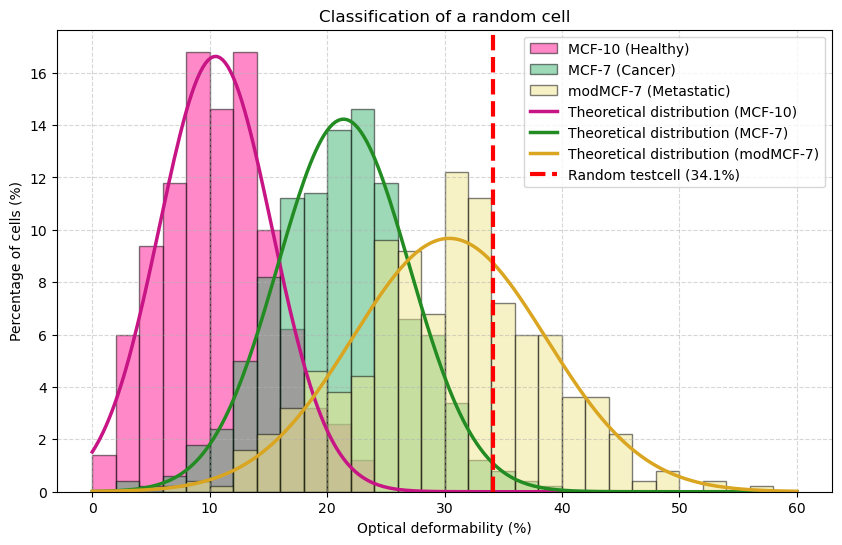

In [22]:
### Printing:

print(f"Classification of a random cell based on probability:")
print()
print(f"The optical deformability of the random cell: {random_cell_OD:.1f}%")
print(f"Most likely: {top_class} ({top_prob:.1f}%)")
print(f"Second most likely: {second_class} ({second_prob:.1f}%)")
print()

# Decision logic based on probability thresholds
if top_prob >= 75.0:
    print(f"Conclusion: The cell is classified as {top_class}, with high certainty.")
elif difference < 25.0:
    print(f"Conclusion: Classification is highly ambiguous, the cell lies in an overlap zone between {top_class} and {second_class}.")
else:
    print(f"Conclusion: Classification is leaning toward {top_class} but with notable overlap causing high ambiguity.")
print()



### Plotting the results: 

# Figure size
plt.figure(figsize=(10, 6))

### Plotting the histograms from the generated data: --------------------------------------

# Choosing a bin size
n_bins = 30
data_range = (0, 60)

# Calculate weights to convert counts into percentages (summing to 100% per dataset)
weight_healthy = np.ones_like(healthy_data) * 100.0 / len(healthy_data)
weight_cancer = np.ones_like(cancer_data) * 100.0 / len(cancer_data)
weight_meta = np.ones_like(meta_data) * 100.0 / len(meta_data)

# Histogram for normal cells
count_healthy, bins_healthy, _ = plt.hist(healthy_data, bins=n_bins, range=data_range, alpha=0.5, color='deeppink', label='MCF-10 (Healthy)', edgecolor='black', weights=weight_healthy)
bin_width = bins_healthy[1] - bins_healthy[0]

# Histogram for cancer cells
count_cancer, bins_cancer, _ = plt.hist(cancer_data, bins=n_bins, range=data_range, alpha=0.5, color='mediumseagreen', label='MCF-7 (Cancer)', edgecolor='black', weights=weight_cancer)

# Histogram for metastatic cells
count_meta, bins_meta, _ = plt.hist(meta_data, bins=n_bins, range=data_range, alpha=0.5, color='khaki', label='modMCF-7 (Metastatic)', edgecolor='black', weights=weight_meta)

### Plotting the perfect normal distribution -----------------------------------------------

# Create x-values 
x_axis = np.linspace(0, 60, 250)

# Calculate the normal distribution 
y_ideal_healthy = normal_distribution(x_axis, mu_healthy, sigma_healthy) * 100 * bin_width
y_ideal_cancer = normal_distribution(x_axis, mu_cancer, sigma_cancer) * 100 * bin_width
y_ideal_meta = normal_distribution(x_axis, mu_meta, sigma_meta) * 100 * bin_width

# Plot the perfect lines
plt.plot(x_axis, y_ideal_healthy, color='mediumvioletred', linewidth=2.5, label='Theoretical distribution (MCF-10)')
plt.plot(x_axis, y_ideal_cancer, color='forestgreen', linewidth=2.5, label='Theoretical distribution (MCF-7)')
plt.plot(x_axis, y_ideal_meta, color='goldenrod', linewidth=2.5, label='Theoretical distribution (modMCF-7)')

### Plot the random cell -----------------------------------------------------------------

plt.axvline(x=random_cell_OD, color='red', linestyle='--', linewidth=3, label=f'Random testcell ({random_cell_OD:.1f}%)')

# Plotting settings -----------------------------------------------------------------------
plt.title('Classification of a random cell')
plt.xlabel('Optical deformability (%)')
plt.ylabel('Percentage of cells (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Backwards simulation and validating using bootstrap

In [6]:
# BACKWARD: estimating the parameters from the simulated data 

# Estimate mean
estimated_mu_healthy = np.mean(healthy_data)
estimated_mu_cancer = np.mean(cancer_data)
estimated_mu_meta = np.mean(meta_data)

# Estimate standard deviation
estimated_sigma_healthy = np.std(healthy_data, ddof=1)
estimated_sigma_cancer = np.std(cancer_data, ddof=1)
estimated_sigma_meta = np.std(meta_data, ddof=1)

print("MCF-10A - Healthy")
print("Original mean:", mu_healthy) 
print("Estimated mean:", round(estimated_mu_healthy, 5)) 
print("Original SD:", sigma_healthy) 
print("Estimated SD:", round(estimated_sigma_healthy, 5))

print("\nMCF-7 - Cancer") 
print("Original mean:", mu_cancer) 
print("Estimated mean:", round(estimated_mu_cancer, 5)) 
print("Original SD:", sigma_cancer) 
print("Estimated SD:", round(estimated_sigma_cancer, 5))

print("\nmodMCF-7 - Metastatic") 
print("Original mean:", mu_meta) 
print("Estimated mean:", round(estimated_mu_meta, 5)) 
print("Original SD:", sigma_meta) 
print("Estimated SD:", round(estimated_sigma_meta, 5))

MCF-10A - Healthy
Original mean: 10.5
Estimated mean: 10.76638
Original SD: 4.800000000000001
Estimated SD: 4.68591

MCF-7 - Cancer
Original mean: 21.4
Estimated mean: 21.13207
Original SD: 5.608921464952063
Estimated SD: 5.75054

modMCF-7 - Metastatic
Original mean: 30.4
Estimated mean: 30.20713
Original SD: 8.248636250920512
Estimated SD: 8.17379


#### Bootstrap 

In [7]:
# Define number of Bootstrap iterations
B = 2000

# Weighted selection function
def choose(r, probs):
    running = 0.0
    for k in range(len(probs)):
        running = running + probs[k]
        if r < running:
            return k
    return len(probs) - 1

# Lengths of the datasets (since the size was chosen to be 500, this will be 500 for all datasets)
N_healthy = len(healthy_data) # = 500
N_cancer = len(cancer_data) # = 500
N_meta = len(meta_data) # = 500

# Create lists with N length, with 1/N in every element to create equal probabilities 
equal_healthy = [1 / N_healthy] * N_healthy 
equal_cancer = [1 / N_cancer] * N_cancer
equal_meta = [1 / N_meta] * N_meta

# Random numbers needed for all resamples 
rs_healthy = uniforms(B * N_healthy, seed=8) 
rs_cancer = uniforms(B * N_cancer, seed=20)
rs_meta = uniforms(B * N_meta, seed=40)

# Initializing lists to store the mean of each bootstrap dataset
boot_means_healthy = [0.0] * B 
boot_means_cancer = [0.0] * B
boot_means_meta = [0.0] * B

for b in range(B):
    resample_healthy = [0.0] * N_healthy 
    resample_cancer = [0.0] * N_cancer
    resample_meta = [0.0] * N_meta

    # Resample healthy cells
    for i in range(N_healthy): 
        j = choose(rs_healthy[b * N_healthy + i], equal_healthy) 
        resample_healthy[i] = healthy_data[j]

    # Resample cancer cells 
    for i in range(N_cancer): 
        j = choose(rs_cancer[b * N_cancer + i], equal_cancer) 
        resample_cancer[i] = cancer_data[j]  
    
    # Resample metastatic cells
    for i in range(N_meta): 
        j = choose(rs_meta[b * N_meta + i], equal_meta) 
        resample_meta[i] = meta_data[j]

    # Calculate the mean for bootstrap sample b and store in the lists previously created
    boot_means_healthy[b] = np.mean(resample_healthy) 
    boot_means_cancer[b] = np.mean(resample_cancer)
    boot_means_meta[b] = np.mean(resample_meta)

# Calculate the mean of all bootstrap estimates 
bootstrap_mean_healthy = np.mean(boot_means_healthy) 
bootstrap_mean_cancer = np.mean(boot_means_cancer) 
bootstrap_mean_meta = np.mean(boot_means_meta) 

# Calculate the Bootstrap uncertainty by calculating the standard deviation of each list of Bootstrap means  
uncertainty_healthy = np.std(boot_means_healthy, ddof=1) 
uncertainty_cancer = np.std(boot_means_cancer, ddof=1)
uncertainty_meta = np.std(boot_means_meta, ddof=1)

### Printing -------------------------------------------------------

print("MCF-10A - Healthy") 
print("Original mean:", mu_healthy) 
print("Estimated mean from backwards simulation:", round(estimated_mu_healthy, 2)) 
print("Bootstrap mean:", round(bootstrap_mean_healthy, 2)) 
print("Bootstrap uncertainty:", round(uncertainty_healthy, 2)) 
print("Bootstrap result:", round(bootstrap_mean_healthy, 2), "±", round(uncertainty_healthy, 2))

print() 

print("MCF-7 - Cancer") 
print("Original mean:", mu_cancer) 
print("Estimated mean from backwards simulation:", round(estimated_mu_cancer, 2)) 
print("Bootstrap mean:", round(bootstrap_mean_cancer, 2)) 
print("Bootstrap uncertainty:", round(uncertainty_cancer, 2))
print("Bootstrap result:", round(bootstrap_mean_cancer, 2), "±", round(uncertainty_cancer, 2))

print() 

print("modMCF-7 - Metastatic") 
print("Original mean:", mu_meta) 
print("Estimated mean from backwards simulation:", round(estimated_mu_meta, 2)) 
print("Bootstrap mean:", round(bootstrap_mean_meta, 2)) 
print("Bootstrap uncertainty:", round(uncertainty_meta, 2))
print("Bootstrap result:", round(bootstrap_mean_meta, 2), "±", round(uncertainty_meta, 2))

MCF-10A - Healthy
Original mean: 10.5
Estimated mean from backwards simulation: 10.77
Bootstrap mean: 10.76
Bootstrap uncertainty: 0.21
Bootstrap result: 10.76 ± 0.21

MCF-7 - Cancer
Original mean: 21.4
Estimated mean from backwards simulation: 21.13
Bootstrap mean: 21.14
Bootstrap uncertainty: 0.26
Bootstrap result: 21.14 ± 0.26

modMCF-7 - Metastatic
Original mean: 30.4
Estimated mean from backwards simulation: 30.21
Bootstrap mean: 30.21
Bootstrap uncertainty: 0.36
Bootstrap result: 30.21 ± 0.36
